# Experiment 1: Quantum Cryptography and the BB84 Protocol

## 1. Introduction and Motivation
In classical cryptography, secure communication relies on mathematical complexity. Protocols like RSA assume that factoring massive prime numbers is computationally unfeasible for an eavesdropper. However, the advent of quantum computing threatens to break these mathematical vaults using algorithms like Shor's algorithm.

**Quantum Key Distribution (QKD)**, specifically the **BB84 Protocol**, offers a paradigm shift: security guaranteed not by math, but by the fundamental laws of physics. 

## 2. The Goal of this Experiment
Our objective is to establish a secure cryptographic key between a sender (Alice) and a receiver (Bob) over a simulated quantum channel. We will:
1. Simulate the transmission of individual qubits encoded with random information.
2. Perform "Key Sifting" to extract a shared secret key.
3. Introduce an eavesdropper (Eve) to the channel.
4. Prove that quantum mechanics (specifically, the observer effect and the no-cloning theorem) makes it physically impossible for Eve to intercept the key without alerting Alice and Bob.

## 3. The Theoretical Framework
Alice will encode classical bits (0 or 1) into quantum states using two different bases:
* **Standard Basis ($Z$-basis):** Uses states $|0\rangle$ and $|1\rangle$.
* **Superposition Basis ($X$-basis):** Uses states $|+\rangle$ and $|-\rangle$, created by applying a Hadamard gate ($H$).

Because Bob does not know which basis Alice used for each qubit, he must guess. If he guesses correctly, he measures the exact bit Alice sent. If he guesses incorrectly, he forces a superposition state to collapse randomly, yielding garbage data. They will later compare their bases publicly and discard the garbage data, leaving a perfect, shared cryptographic key.

In [1]:
# =====================================================================
# IMPORTS AND ENVIRONMENT SETUP
# We begin by importing the necessary quantum mechanics simulators,
# visualization tools, and statistical libraries.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector
from qiskit import qasm2

# Setting a fixed seed ensures our experiment is reproducible
np.random.seed(42)
simulator = AerSimulator()

## 4. Engineering the IPC (Inter-Process Communication) Architecture
To make this experiment realistic, we will not build a single, static circuit. Instead, we will simulate an asynchronous communication network. 

We will define three distinct entities:
* **Alice:** Generates the raw bits and encodes them into a `QuantumCircuit` (representing a flying photon).
* **The Quantum Channel:** The medium (like a fiber optic cable) that transports the `QuantumCircuit`.
* **Bob:** Receives the `QuantumCircuit` from the channel, chooses a random measurement basis, and extracts a classical bit.

In [2]:
# =====================================================================
# ENTITY DEFINITIONS: ALICE, BOB, AND THE QUANTUM CHANNEL
# We utilize an object-oriented approach to isolate the logic of each
# participant. Alice creates the state, Bob measures it.
# =====================================================================

class Alice:
    def __init__(self, num_bits):
        self.num_bits = num_bits
        self.bits = np.random.randint(2, size=num_bits)
        self.bases = np.random.randint(2, size=num_bits)

    def encode_qubit(self, index):
        qc = QuantumCircuit(1, 1)

        # Encode the bit value: If 1, flip to |1> using an X gate
        if self.bits[index] == 1:
            qc.x(0)

        # Encode the basis: If 1, switch to the X-basis using a Hadamard gate
        if self.bases[index] == 1:
            qc.h(0)

        return qc

class Bob:
    def __init__(self, num_bits):
        self.bases = np.random.randint(2, size=num_bits)
        self.measured_bits = []

    def measure_qubit(self, qc, index):
        # If Bob's random basis choice is 1 (X-basis), he applies a Hadamard
        # before measuring to rotate the state back to the standard Z-basis.
        if self.bases[index] == 1:
            qc.h(0)

        qc.measure(0, 0)
        return qc

class QuantumChannel:
    def __init__(self):
        self.intercept_mode = False
        self.eve = None

    def transmit(self, qc, index):
        if self.intercept_mode and self.eve:
            qc = self.eve.intercept_qubit(qc, index)
        return qc

## 5. Visualizing the Quantum Payloads
Before we run a massive simulation, let us inspect what exactly Alice is sending through the network. We will take a single example where Alice wants to send a `1` using the $X$-basis. 

Mathematically, applying an $X$ gate followed by an $H$ gate creates the state $|-\rangle$. Let's view the OpenQASM assembly instructions and the Bloch sphere representation of this payload.

### OpenQASM Instructions for Payload
```qasm
OPENQASM 2.0;
include "qelib1.inc";
qreg q[1];
creg c[1];
x q[0];
h q[0];
```

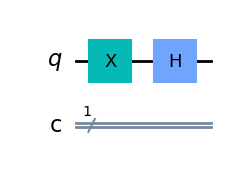

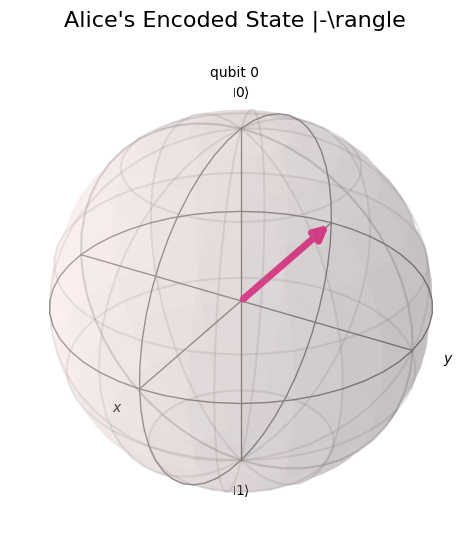

In [3]:
# =====================================================================
# INSPECTING A SINGLE QUBIT PAYLOAD
# We manually trigger Alice's encoding for a specific bit and basis
# to visualize the quantum state before transmission.
# =====================================================================

demo_alice = Alice(1)
demo_alice.bits[0] = 1
demo_alice.bases[0] = 1

demo_circuit = demo_alice.encode_qubit(0)

# Extract the state mathematically before it is measured
state = Statevector.from_instruction(demo_circuit)

# Generate OpenQASM 2.0 instructions for the circuit
qasm_instructions = qasm2.dumps(demo_circuit)
display(Markdown("### OpenQASM Instructions for Payload\n```qasm\n" + qasm_instructions + "\n```"))

# Render the circuit and the Bloch sphere
display(demo_circuit.draw('mpl', style='clifford'))
display(plot_bloch_multivector(state, title="Alice's Encoded State |-\\rangle"))

## 6. Phase 1: Ideal Secure Communication
We will now execute the protocol at scale. Alice will transmit **10,000 qubits** to Bob over the `QuantumChannel`. 

Because a quantum state collapses upon measurement, we can only run `shots=1` for each payload. We will batch these circuits and execute them in bulk to leverage our compute power.

In [4]:
# =====================================================================
# MASS TRANSMISSION SIMULATION
# Alice encodes 10,000 circuits, sends them through the channel, and
# Bob measures them. We collect all circuits into a list for bulk execution.
# =====================================================================

NUM_BITS = 10000

alice = Alice(NUM_BITS)
bob = Bob(NUM_BITS)
channel = QuantumChannel()

circuits_to_run = []

for i in range(NUM_BITS):
    # 1. Alice creates the quantum payload
    payload = alice.encode_qubit(i)

    # 2. Payload traverses the channel
    delivered_payload = channel.transmit(payload, i)

    # 3. Bob applies his measurement logic
    final_circuit = bob.measure_qubit(delivered_payload, i)
    circuits_to_run.append(final_circuit)

# Execute all 10,000 circuits simultaneously on the simulator
job = simulator.run(circuits_to_run, shots=1)
results = job.result()

# Extract Bob's classical bits from the measurements
for i in range(NUM_BITS):
    counts = results.get_counts(i)
    measured_bit = int(list(counts.keys())[0])
    bob.measured_bits.append(measured_bit)

## 7. Key Sifting and Validation
Bob now has 10,000 bits, but they are not all correct. Because Bob guessed his measurement bases, approximately 50% of his measurements were made in the wrong basis, resulting in random noise.

To fix this, Alice and Bob communicate over a standard, public classical channel (like the regular internet). They do not share their bits; they only share their **bases**. They discard any bits where their bases did not match. The remaining bits form the secure key.

We will calculate the **Quantum Bit Error Rate (QBER)** on the final key. In an ideal environment without eavesdroppers, the QBER should be exactly $0.0\%$.

### 🔑 Phase 1 Results: Ideal Channel
- **Total Qubits Sent**: 10000
- **Sifted Key Length**: 4947 bits
- **Quantum Bit Error Rate (QBER)**: **0.0%**


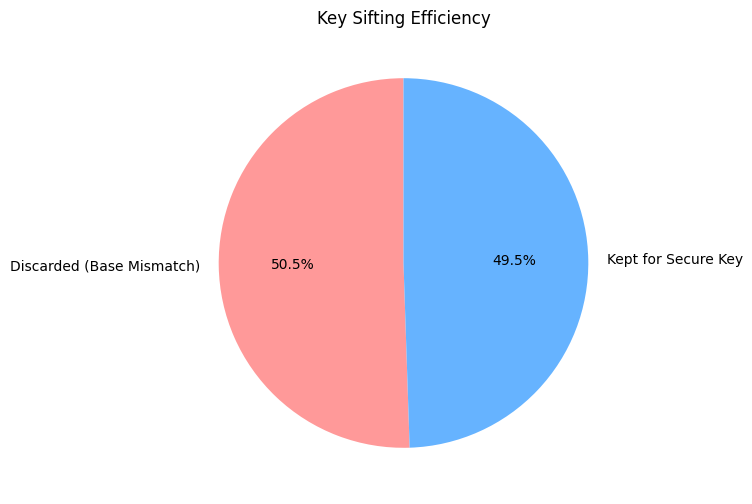

In [5]:
# =====================================================================
# KEY SIFTING AND QBER CALCULATION
# We iterate through the bases. If they match, we append the bit to the
# secure key. We then compare Alice's original bits to Bob's secure key.
# =====================================================================

alice_key = []
bob_key = []

for i in range(NUM_BITS):
    if alice.bases[i] == bob.bases[i]:
        alice_key.append(alice.bits[i])
        bob_key.append(bob.measured_bits[i])

# Calculate errors
errors = 0
for a_bit, b_bit in zip(alice_key, bob_key):
    if a_bit != b_bit:
        errors += 1

qber_ideal = (errors / len(alice_key)) * 100

results_text = "### 🔑 Phase 1 Results: Ideal Channel\n"
results_text += f"- **Total Qubits Sent**: {NUM_BITS}\n"
results_text += f"- **Sifted Key Length**: {len(alice_key)} bits\n"
results_text += f"- **Quantum Bit Error Rate (QBER)**: **{qber_ideal}%**\n"
display(Markdown(results_text))

# Visualize the retention rate of the sifting process
labels = ['Discarded (Base Mismatch)', 'Kept for Secure Key']
values = [NUM_BITS - len(alice_key), len(alice_key)]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title("Key Sifting Efficiency")
plt.show()

## 8. Phase 2: The Quantum Heist (Introducing Eve)
Now we introduce an aggressive threat model. Eve has physically spliced the fiber optic cable in the `QuantumChannel`. 

Her goal is to read the qubits as they pass by, and then send them along to Bob so no one notices they were intercepted. However, the **No-Cloning Theorem** dictates that Eve cannot copy an unknown quantum state. She *must* measure it. 

Because she does not know Alice's bases, Eve must guess, just like Bob. When she guesses wrong, her measurement collapses Alice's carefully prepared superposition into a concrete state, permanently corrupting the payload before it reaches Bob.

In [6]:
# =====================================================================
# DEFINING EVE AND EXECUTING THE INTERCEPTION
# Eve acts as a man-in-the-middle. She intercepts the circuit, applies
# her own measurement, and then passes the collapsed circuit to Bob.
# =====================================================================

class Eve:
    def __init__(self, num_bits):
        self.bases = np.random.randint(2, size=num_bits)

    def intercept_qubit(self, qc, index):
        # Eve guesses a basis and measures the qubit in transit
        if self.bases[index] == 1:
            qc.h(0)

        qc.measure(0, 0)

        # She must "reset" the basis if she used the X-basis so the
        # circuit can continue to Bob, but the state has already collapsed!
        if self.bases[index] == 1:
            qc.h(0)

        return qc

# Initialize a fresh experiment
alice_compromised = Alice(NUM_BITS)
bob_compromised = Bob(NUM_BITS)
channel_compromised = QuantumChannel()

# Inject Eve into the channel
eve = Eve(NUM_BITS)
channel_compromised.intercept_mode = True
channel_compromised.eve = eve

circuits_to_run_compromised = []

for i in range(NUM_BITS):
    payload = alice_compromised.encode_qubit(i)

    # Eve intercepts the payload here!
    delivered_payload = channel_compromised.transmit(payload, i)

    final_circuit = bob_compromised.measure_qubit(delivered_payload, i)
    circuits_to_run_compromised.append(final_circuit)

# Execute the compromised circuits
job_compromised = simulator.run(circuits_to_run_compromised, shots=1)
results_compromised = job_compromised.result()

for i in range(NUM_BITS):
    counts = results_compromised.get_counts(i)
    # The output string now has two bits: Bob's measurement and Eve's measurement.
    # Qiskit reads right-to-left. Bob is bit 0, Eve is bit 1.
    measured_string = list(counts.keys())[0]
    bob_compromised.measured_bits.append(int(measured_string[-1]))

## 9. Analyzing the Disturbance
Alice and Bob perform their standard public Key Sifting process, completely unaware that Eve was listening. 

However, before using the key to encrypt sensitive data, they select a small random subset of their sifted key and publicly compare the actual bit values. 

If Eve intercepted the communication, she will have guessed the wrong basis roughly 50% of the time, transmitting corrupted states to Bob. When Bob measures those corrupted states (even if he guesses the *correct* basis), he will get a randomized result. Mathematically, this guarantees that Eve's presence will introduce an unavoidable **25% error rate** into Alice and Bob's perfectly sifted key. Let's see if our simulation reflects this.

### 🚨 Phase 2 Results: Compromised Channel
- **Compromised QBER**: **25.08058017727639%**

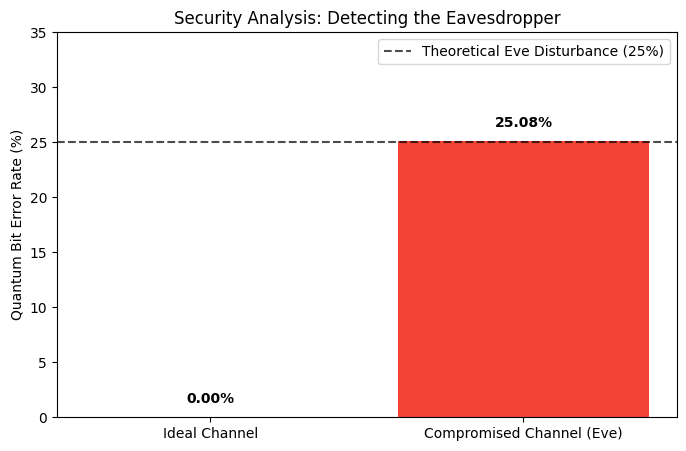

In [7]:
# =====================================================================
# QBER CALCULATION FOR COMPROMISED KEY
# We sift the keys based on Alice and Bob's bases, ignoring Eve entirely,
# and calculate the resulting error rate.
# =====================================================================

alice_key_comp = []
bob_key_comp = []

for i in range(NUM_BITS):
    if alice_compromised.bases[i] == bob_compromised.bases[i]:
        alice_key_comp.append(alice_compromised.bits[i])
        bob_key_comp.append(bob_compromised.measured_bits[i])

errors_comp = 0
for a_bit, b_bit in zip(alice_key_comp, bob_key_comp):
    if a_bit != b_bit:
        errors_comp += 1

qber_compromised = (errors_comp / len(alice_key_comp)) * 100

display(Markdown(f"### 🚨 Phase 2 Results: Compromised Channel\n- **Compromised QBER**: **{qber_compromised}%**"))

# Visualize the stark difference in error rates
scenarios = ['Ideal Channel', 'Compromised Channel (Eve)']
error_rates = [qber_ideal, qber_compromised]

plt.figure(figsize=(8, 5))
bars = plt.bar(scenarios, error_rates, color=['#4CAF50', '#F44336'])
plt.axhline(y=25.0, color='black', linestyle='--', alpha=0.7, label='Theoretical Eve Disturbance (25%)')

plt.ylabel('Quantum Bit Error Rate (%)')
plt.title('Security Analysis: Detecting the Eavesdropper')
plt.ylim(0, 35)
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

## 10. Conclusion
The experiment successfully demonstrates the mechanics of the BB84 protocol.

1.  **Secure Distribution:** We established a shared symmetric key between two distinct entities using superposition and basis-encoding.
2.  **Intrusion Detection:** When the channel was compromised, the resulting QBER spiked to ~25%. 

In a real-world scenario, Alice and Bob would set an abort threshold (e.g., if QBER > 11%). Seeing a ~25% error rate, they would immediately know the channel is tapped, discard the compromised key, and attempt communication over a different channel. Eve is left with a string of measurements, but because she caused the protocol to abort, she possesses a key to a lock that will never be used. The data remains entirely secure.

## 11. Bibliography & Further Reading

1. **Bennett, C. H., & Brassard, G. (1984).** *Quantum cryptography: Public key distribution and coin tossing*. Proceedings of IEEE International Conference on Computers, Systems and Signal Processing, 175-179.
2. **IBM Quantum Learning:** [Quantum Key Distribution](https://learning.quantum.ibm.com/course/quantum-communication/quantum-key-distribution)
3. **Wikipedia:** [BB84 Protocol](https://en.wikipedia.org/wiki/BB84)